©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、情報理論の基本概念をPythonで実装します。情報量（自己情報量）、エントロピー、KLダイバージェンス、交差エントロピー、自己相互情報量（PMI）といった指標を数式に基づいてコーディングし、確率分布間の類似度や情報量の意味を数値的に確認します。<br />
※E資格では数学・統計分野のコード実装は出題されません。当Notebookでは、参考資料として、数学・統計学分野のコード実装例をご参考ください。

# 事前準備

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）


In [ ]:
# %%capture
# !pip uninstall matplotlib -y
# !pip install matplotlib==3.9.3

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.10.0.84

# !pip uninstall tensorflow -y
# !pip install tensorflow==2.18.0

# !pip uninstall torch -y
# !pip install torch==2.5.1

# !pip uninstall torchvision -y
# !pip install torchvision==0.20.1

# 情報量の概念


In [ ]:
import numpy as np
import scipy as sp
import seaborn as sns

In [ ]:
def plot_bar_graph(prob_distro):
    """ 確率分布の棒グラフを描画 """
    sns.barplot(x=list(prob_distro.keys()), y=list(prob_distro.values()))

In [ ]:
# 確率分布A
prob_distro_a = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}

# 確率分布B
prob_distro_b = {0: 0.25, 1: 0.4, 2: 0.2, 3: 0.15}

# 確率分布C
prob_distro_c = {0: 0.2, 1: 0.1, 2: 0.6, 3: 0.1}

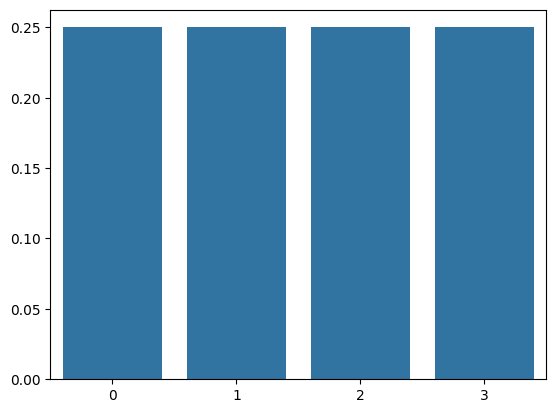

In [ ]:
plot_bar_graph(prob_distro_a)

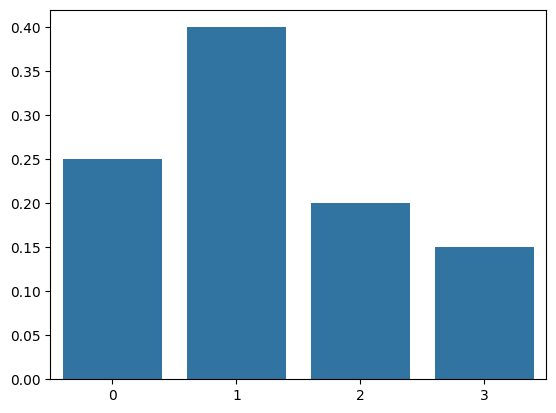

In [ ]:
plot_bar_graph(prob_distro_b)

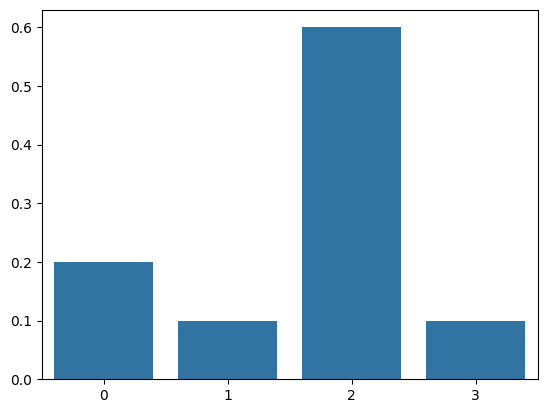

In [ ]:
plot_bar_graph(prob_distro_c)

## エントロピー

In [ ]:
def calc_entropy(prob_distro):
    """エントロピーを計算"""
    result = 0
    for prob in prob_distro.values():
        # probが0のときはnp.log2(prob)が-infになってしまうので無視する（H(0)≡0として扱っているのと同義）
        if prob == 0:
            continue
        result += - prob * np.log2(prob)
    return result

In [ ]:
# 分布が一様なAはエントロピーが大きい
calc_entropy(prob_distro_a)

np.float64(2.0)

In [ ]:
calc_entropy(prob_distro_b)

np.float64(1.9037016960573483)

In [ ]:
# 各確率の異なりの大きい分布Cはエントロピーが小さい
calc_entropy(prob_distro_c)

np.float64(1.5709505944546687)

In [ ]:
# scipyのエントロピーを計算する関数
sp.stats.entropy(list(prob_distro_c.values()), base=2)

np.float64(1.5709505944546687)

## KLダイバージェンス

In [ ]:
def calc_kl_div(prob_distro_1, prob_distro_2):
    """KLダイバージェンスを計算"""
    result = 0
    for prob1, prob2 in zip(prob_distro_1.values(), prob_distro_2.values()):
        # prob2に0が含まれる場合、KLダイバージェンスは定義より計算できない→スムージングで例外対応することは可能
        # https://mathoverflow.net/questions/72668/how-to-compute-kl-divergence-when-pmf-contains-0s
        if prob2 == 0:
            raise AssertionError("KL divergence can't handle zeros.")
        result += prob1 * np.log2(prob1 / prob2)
    return result

In [ ]:
# 分布が一致するとKLダイバージェンスは0
calc_kl_div(prob_distro_a, prob_distro_a)

np.float64(0.0)

In [ ]:
calc_kl_div(prob_distro_a, prob_distro_b)

np.float64(0.09520544598523271)

In [ ]:
# 分布Aから見た分布Bは、分布Aから見た分布CよりもKLダイバージェンス（異なり）が小さい
calc_kl_div(prob_distro_a, prob_distro_c)

np.float64(0.4256874697070734)

## 交差エントロピー

In [ ]:
def calc_cross_entropy(prob_distro_1, prob_distro_2):
    """ 交差エントロピーを計算 """
    result_intermediate = 0
    for prob1, prob2 in zip(prob_distro_1.values(), prob_distro_2.values()):
        if prob2 == 0:
            # np.log2(0)=0として扱ってるのと同義
            continue
        result_intermediate += prob1 * np.log2(prob2)
    return -result_intermediate

In [ ]:
# 分布Aのエントロピーに等しい
calc_cross_entropy(prob_distro_a, prob_distro_a)

np.float64(2.0)

In [ ]:
calc_cross_entropy(prob_distro_a, prob_distro_b)

np.float64(2.0952054459852327)

In [ ]:
# 分布A（一様）かつ分布A、Cは異なりが大きい→交差エントロピー最大
calc_cross_entropy(prob_distro_a, prob_distro_c)

np.float64(2.425687469707073)

In [ ]:
# 分布Aと分布Bの交差エントロピー＝分布Aのエントロピー＋分布Aから見たBのKLダイバージェンスの和
calc_cross_entropy(prob_distro_a, prob_distro_b) == calc_entropy(prob_distro_a) + calc_kl_div(prob_distro_a, prob_distro_b)

np.True_

## 自己相互情報量（Pointwise Mutual Information, PMI）

In [ ]:
# X,Yの同時確率分布
joint_prob_distro_xy = {
    0: {0: 0.05, 1: 0.10, 2: 0.10, 3:0.05},
    1: {0: 0.05, 1: 0.05, 2: 0.05, 3:0.05},
    2: {0: 0.01, 1: 0.02, 2: 0.04, 3:0.03},
    3: {0: 0.05, 1: 0.05, 2: 0.20, 3:0.10},
}

# 同時分布の中身の合計が1になってるか確認
sum([sum(prob_distro.values()) for prob_distro in joint_prob_distro_xy.values()]) == 1.0

True

In [ ]:
def calc_pmi(x, y, prob_distro_x, prob_distro_y, joint_prob_distro_xy):
    """ 自己相互情報量を計算 """
    return np.log2(joint_prob_distro_xy[x][y] / (prob_distro_x[x] * prob_distro_y[y]))

In [ ]:
calc_pmi(0, 1, prob_distro_a, prob_distro_b, joint_prob_distro_xy)  # log2(0.1/(0.25*0.4))=log2(1)

np.float64(0.0)

In [ ]:
calc_pmi(3, 2, prob_distro_a, prob_distro_b, joint_prob_distro_xy)  # log2(0.2/(0.25*0.2))=log2(4)

np.float64(2.0)

In [ ]:
calc_pmi(2, 0, prob_distro_a, prob_distro_b, joint_prob_distro_xy)  # log2(0.01/(0.25*0.25))=log2(0.16)

np.float64(-2.643856189774725)